# Neural Network and Final Analysis
### Build the non-linear model and lead the final model comparison.

## 1. Imports

In [60]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Setup:

In [61]:
# tell python to stop printing warning messages
warnings.filterwarnings("ignore")

# set default visual style for all the matplotlib and seaborn plots
sns.set_theme(style="whitegrid", palette="muted")

# set default size of every plot.
plt.rcParams["figure.figsize"] = (8, 5)

PAIRS_CSV = "dataset/pairs_dataset.csv"
SPLIT_CSV = "dataset/split_indices.csv"
DIST_COL  = "site_distance_km"
GROUP_COL = "EQID"
TARGET    = "delta_theta"
DROP_COLS = ["Earthquake Name", "Station Name", "RSN_1", "RSN_2"]
SEED      = 42
os.makedirs("results/figures", exist_ok=True)

## Load data and features

In [62]:
df = pd.read_csv(PAIRS_CSV)  #loads csv file into dataframe
print("Shape:", df.shape, "| target:", TARGET, "| earthquakes:", df[GROUP_COL].nunique()) # prints (rows, columns), df[GROUP_COL].nunique() : Counts how many unique earthqakes are in the data.

groups = df[GROUP_COL].values 

feat_pre = df.drop(columns=[c for c in DROP_COLS + [TARGET, "delta_ln_pga", GROUP_COL]
                            if c in df.columns])
cat_cols = feat_pre.select_dtypes(exclude=[np.number]).columns.tolist()
X = pd.get_dummies(feat_pre, columns=cat_cols, drop_first=True, dtype=float)
y = df[TARGET].values

attr_map = {a: [c for c in X.columns if c == a or c.startswith(a + "_")]
            for a in feat_pre.columns}
print(f"{len(attr_map)} attributes → {X.shape[1]} model columns")

Shape: (6227, 17) | target: delta_theta | earthquakes: 86
15 attributes → 24 model columns


## LOAD The shared split

In [63]:
sp = pd.read_csv(SPLIT_CSV)["split"].values
assert len(sp) == len(df), "split file mismatch — rerun make_split.py"

train_idx, val_idx, test_idx = [np.where(sp == k)[0] for k in ("train", "val", "test")]
for n, i in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    print(f"{n:5s}: {len(i):6d} pairs, {len(np.unique(groups[i])):4d} earthquakes, "
          f"mean target {y[i].mean():.3f}")

Xtr, Xva, Xte = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
ytr, yva, yte = y[train_idx], y[val_idx], y[test_idx]
gtr = groups[train_idx]
SETS = {"train": (Xtr, ytr), "val": (Xva, yva), "test": (Xte, yte)}

train:   4192 pairs,   60 earthquakes, mean target 2.316
val  :   1274 pairs,   13 earthquakes, mean target 1.840
test :    761 pairs,   13 earthquakes, mean target 1.786


## Metrics Helper

In [64]:
def metrics(name, split, y_true, y_pred):
    return dict(model=name, split=split,
                R2=r2_score(y_true, y_pred),
                MAE=mean_absolute_error(y_true, y_pred),
                RMSE=np.sqrt(mean_squared_error(y_true, y_pred)))

results = []

## Mean predictor baseline

In [65]:
results += [metrics("Mean predictor", s, yy, np.full_like(yy, ytr.mean(), dtype=float))
            for s, (_, yy) in SETS.items()]
pd.DataFrame(results).round(4)

,model,split,R2,MAE,RMSE
0,Mean predictor,train,0.0000,2.4819,5.8626
1,Mean predictor,val,-0.0270,1.7346,2.9368
2,Mean predictor,test,-0.0123,2.3616,4.8104


## Baseline Neural Network

In [66]:
base_nn = Pipeline([
    ("sc", StandardScaler()),
    ("nn", MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                        solver="adam", alpha=0.001, max_iter=2000,
                        early_stopping=True, n_iter_no_change=20,
                        random_state=SEED))
]).fit(Xtr, ytr)

base_pred = {s: base_nn.predict(Xs) for s, (Xs, _) in SETS.items()}
for s, (_, yy) in SETS.items():
    results.append(metrics("NN (baseline)", s, yy, base_pred[s]))
pd.DataFrame(results).query("model == 'NN (baseline)'").round(4)

,model,split,R2,MAE,RMSE
3,NN (baseline),train,0.2371,1.8695,5.1206
4,NN (baseline),val,0.2068,1.5388,2.5809
5,NN (baseline),test,0.3091,1.4000,3.9742


## Hyperparameter tuning via GroupKFold CV on the training set

In [67]:
cv = GroupKFold(n_splits=5)
folds = list(cv.split(Xtr, ytr, gtr))

param_grid = {
    "nn__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64),
                                (128, 64, 32), (256, 128), (256, 128, 64)],
    "nn__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0],
}

grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()),
              ("nn", MLPRegressor(activation="relu", solver="adam",
                                   max_iter=2000, early_stopping=True,
                                   n_iter_no_change=20, random_state=SEED))]),
    param_grid,
    cv=folds,           
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)
grid.fit(Xtr, ytr)
print("\nBest params:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 4))

Fitting 5 folds for each of 35 candidates, totalling 175 fits

Best params: {'nn__alpha': 0.0001, 'nn__hidden_layer_sizes': (256, 128, 64)}
Best CV R²: 0.2153


## Evaluate tuned NN on train / val / test

In [68]:
best_nn = grid.best_estimator_

nn_pred = {s: best_nn.predict(Xs) for s, (Xs, _) in SETS.items()}
for s, (_, yy) in SETS.items():
    results.append(metrics("Neural network", s, yy, nn_pred[s]))

res = pd.DataFrame(results)
res.pivot(index="model", columns="split", values=["R2", "MAE", "RMSE"]).round(4)

R2                     MAE                    RMSE  \
split             test   train     val    test   train     val    test   
model                                                                    
Mean predictor -0.0123  0.0000 -0.0270  2.3616  2.4819  1.7346  4.8104   
NN (baseline)   0.3091  0.2371  0.2068  1.4000  1.8695  1.5388  3.9742   
Neural network  0.4642  0.7001  0.2558  1.1764  1.1508  1.2008  3.4998   

                                
split            train     val  
model                           
Mean predictor  5.8626  2.9368  
NN (baseline)   5.1206  2.5809  
Neural network  3.2106  2.5000

## Grouped 5-fold CV across all data (the harder, more honest evaluation)

In [69]:
cv5 = GroupKFold(n_splits=5)
rows = []

for k, (a, b) in enumerate(cv5.split(X, y, groups)):
    pipe = Pipeline([("sc", StandardScaler()),
                     ("nn", MLPRegressor(**{key.split("__")[1]: val
                                             for key, val in grid.best_params_.items()},
                                          activation="relu", solver="adam",
                                          max_iter=2000, early_stopping=True,
                                          n_iter_no_change=20, random_state=SEED))])
    pipe.fit(X.iloc[a], y[a])
    p = pipe.predict(X.iloc[b])
    rows.append(dict(fold=k, model="Neural network",
                     R2=r2_score(y[b], p),
                     MAE=mean_absolute_error(y[b], p),
                     RMSE=np.sqrt(mean_squared_error(y[b], p))))

cv_df = pd.DataFrame(rows)
cv_summary = cv_df.groupby("model")[["R2", "MAE", "RMSE"]].agg(["mean", "std"]).round(4)
cv_df.to_csv("results/cv_member3_folds.csv", index=False)
cv_summary.to_csv("results/cv_member3_summary.csv")
cv_summary

R2             MAE            RMSE        
                  mean     std    mean     std    mean     std
model                                                         
Neural network  0.1587  0.1922  1.5851  0.5987  4.1445  2.4641

In [70]:
test_row = [metrics("Neural network", "test",
                    yte, nn_pred["test"])]
cv_rows = [dict(model="Neural network", split="cv5_mean",
                R2=cv_df["R2"].mean(),
                MAE=cv_df["MAE"].mean(),
                RMSE=cv_df["RMSE"].mean())]

m3 = pd.DataFrame(test_row + cv_rows)
m3.round(5).to_csv("results/metrics_member3.csv", index=False)
print("Saved results/metrics_member3.csv")
m3

Saved results/metrics_member3.csv


,model,split,R2,MAE,RMSE
0,Neural network,test,0.464204,1.176363,3.499754
1,Neural network,cv5_mean,0.158708,1.585139,4.144531


## Plots

### True vs predicted on train & test

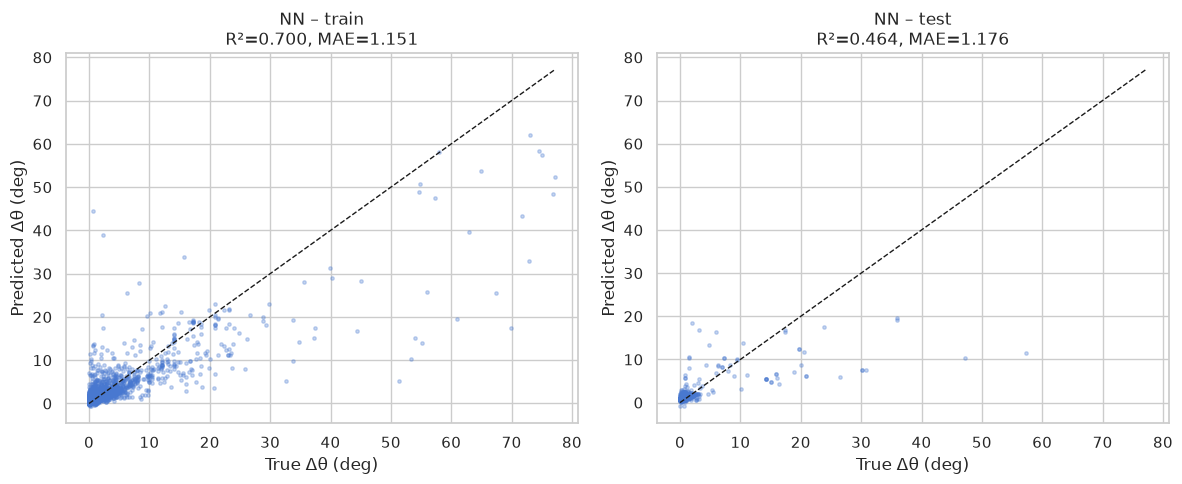

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lim = [0, y.max()]
for c, s in enumerate(["train", "test"]):
    yy = SETS[s][1]; p = nn_pred[s]
    ax[c].scatter(yy, p, s=6, alpha=0.3)
    ax[c].plot(lim, lim, "k--", lw=1)
    ax[c].set_title(f"NN – {s}\nR²={r2_score(yy,p):.3f}, MAE={mean_absolute_error(yy,p):.3f}")
    ax[c].set_xlabel("True Δθ (deg)"); ax[c].set_ylabel("Predicted Δθ (deg)")
plt.tight_layout(); plt.savefig("results/figures/m3_true_vs_pred.png", dpi=150); plt.show()

### Loss curve of the best model (train vs internal validation)

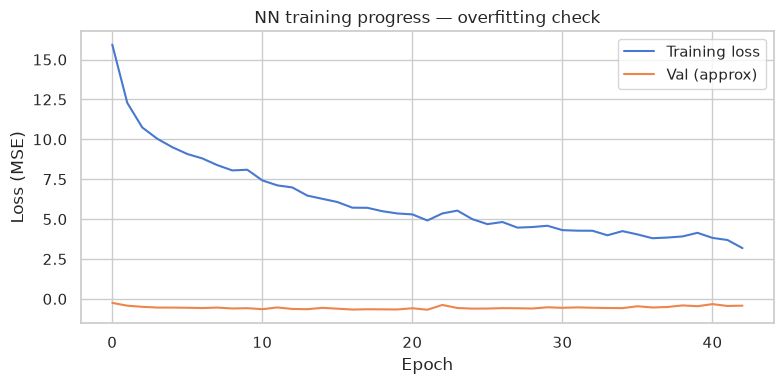

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(best_nn.named_steps["nn"].loss_curve_, label="Training loss")
if best_nn.named_steps["nn"].validation_scores_ is not None:
    plt.plot(-np.array(best_nn.named_steps["nn"].validation_scores_), label="Val (approx)")
plt.xlabel("Epoch"); plt.ylabel("Loss (MSE)"); plt.legend()
plt.title("NN training progress — overfitting check")
plt.tight_layout(); plt.savefig("results/figures/m3_loss_curve.png", dpi=150); plt.show()

### Bar chart comparison across all models

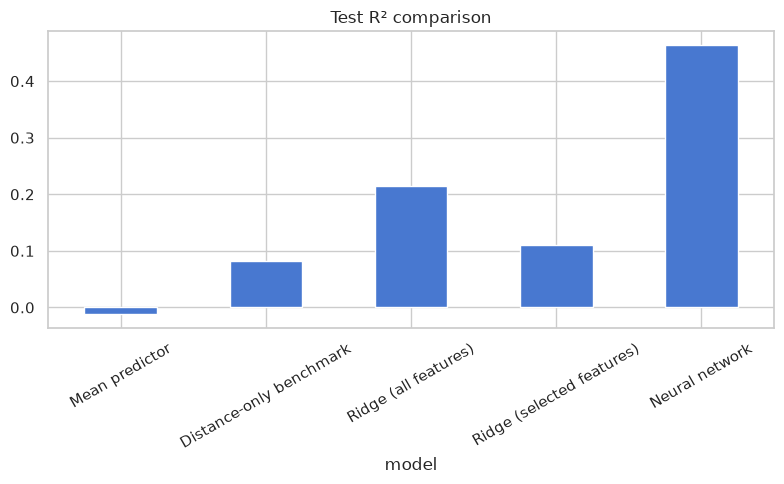

In [73]:
m2 = pd.read_csv("results/metrics_member2.csv")
comp = pd.concat([m2, m3], ignore_index=True)
test_only = comp[comp["split"] == "test"]
test_only.plot.bar(x="model", y=["R2"], rot=30, legend=False)
plt.title("Test R² comparison"); plt.tight_layout()
plt.savefig("results/figures/m3_final_comparison.png", dpi=150); plt.show()

### Sanity check: load everything and print final table

In [74]:
m2 = pd.read_csv("results/metrics_member2.csv")
m3 = pd.read_csv("results/metrics_member3.csv")
final = pd.concat([m2, m3], ignore_index=True)
final.to_csv("results/metrics_final_comparison.csv", index=False)
final.round(4)

,model,split,R2,MAE,RMSE
0,Mean predictor,train,0.0000,2.4819,5.8626
1,Mean predictor,val,-0.0270,1.7346,2.9368
2,Mean predictor,test,-0.0123,2.3616,4.8104
3,Distance-only benchmark,train,0.0426,2.3364,5.7364
4,Distance-only benchmark,val,0.1752,1.2134,2.6319
5,Distance-only benchmark,test,0.0829,1.6611,4.5786
6,Ridge (all features),train,0.2215,1.9058,5.1727
7,Ridge (selected features),train,0.2271,1.8944,5.1540
8,Ridge (all features),val,0.1026,1.7618,2.7452
9,Ridge (selected features),val,-0.0337,2.0014,2.9464
